In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.feature as cfeature


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut

In [2]:
# set up LDA 

# potential predictor variable X = oni 
# classification variable t = tercile ranking of the rainfall in subsequent season
# -> discriminant analysis calculates the conditional probability, P(t|X'), of occurrence of class t given a new observation X'
# for each of the three possible classes (above normal, near normal, below normal) 
# (Drosdowsky and Chambers, 2000)

In [3]:
singlegrid= xr.open_dataset('data/singlegrid.nc')
singlegrid 

singlegrid_series = singlegrid['precip'].to_series()
singlegrid_series

time
1900-01-16 00:00:00    41.001965
1900-02-14 12:00:00    16.001106
1900-03-16 00:00:00    63.117325
1900-04-15 12:00:00    40.177437
1900-05-16 00:00:00    50.528648
                         ...    
2025-08-16 00:00:00    31.472557
2025-09-15 12:00:00    29.625412
2025-10-16 00:00:00    22.634979
2025-11-15 12:00:00    36.333515
2025-12-16 00:00:00    36.652603
Name: precip, Length: 1512, dtype: float32

In [4]:
# oni
oni_ersst = xr.open_dataset('data/oni.nc')

oni_series = oni_ersst['value'].to_series()
oni_series

# roni 
roni_ersst = xr.open_dataset('data/roni.nc')

roni_series = roni_ersst['value'].to_series()
roni_series

time
1949-01-01     NaN
1949-02-01     NaN
1949-03-01     NaN
1949-04-01     NaN
1949-05-01     NaN
              ... 
2026-04-01   -0.13
2026-05-01    0.52
2026-06-01    1.07
2026-07-01    1.33
2026-08-01    1.67
Name: value, Length: 932, dtype: float32

In [5]:
# HadISST oni and roni calculation 

hadisst = xr.open_dataset('data/HadISST_sst.nc')
hadisst
# print(hadsst['sst'].compute())


<xarray.Dataset> Size: 487MB
Dimensions:    (time: 1879, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 15kB ...
    sst        (time, latitude, longitude) float32 487MB ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    3/9/2026 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

In [6]:
# Niño 3.4 region (5°N–5°S, 120–170°W)

nino34 = hadisst['sst'].sel(
    latitude=slice(5, -5),
    longitude=slice(-170, -120)
)
# print (nino34)

nino34_sst = nino34.mean(
    dim=['latitude', 'longitude'],
    skipna=True
)
# print (nino34_sst)

clim = (
    nino34_sst
    .sel(time=slice('1991-01', '2020-12'))
    .groupby('time.month')
    .mean('time')
)

nino34_anom = nino34_sst.groupby('time.month') - clim

# print (nino34_anom)

oni = nino34_anom.rolling(time=3, center=True).mean()
oni

<xarray.DataArray 'sst' (time: 1879)> Size: 8kB
array([       nan, -1.0212358, -0.989179 , ...,  0.7424838,  1.2523651,
              nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
    month    (time) int64 15kB 1 2 3 4 5 6 7 8 9 10 ... 10 11 12 1 2 3 4 5 6 7

In [7]:
# calculate tropical sst climatology 
tropical = hadisst['sst'].sel(
    latitude=slice(20, -20)
)

tropical_sst = tropical.mean( # spatial mean of entire tropical -> single time series 
    dim=['latitude', 'longitude'],
    skipna = True
)

tropical_clim = ( # base climatology of entire tropical SST 1991-2020
    tropical_sst
    .sel(time=slice('1991-01', '2020-12'))
    .groupby('time.month')
    .mean('time')
)

tropical_anom = ( # anomaly of entire tropcial SST 
    tropical_sst.groupby('time.month')
    - tropical_clim
)

roni_monthly = nino34_anom - tropical_anom

roni = roni_monthly.rolling(time=3, center=True).mean()

roni


<xarray.DataArray 'sst' (time: 1879)> Size: 8kB
array([        nan, -0.47344908, -0.38168845, ...,  0.38390478,
        0.7964058 ,         nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
    month    (time) int64 15kB 1 2 3 4 5 6 7 8 9 10 ... 10 11 12 1 2 3 4 5 6 7

In [8]:
print(oni.time.min().values)
print(oni.time.max().values)

print(roni.time.min().values)
print(roni.time.max().values)

1870-01-16T11:59:59.505615234
2026-07-16T12:00:00.000000000
1870-01-16T11:59:59.505615234
2026-07-16T12:00:00.000000000


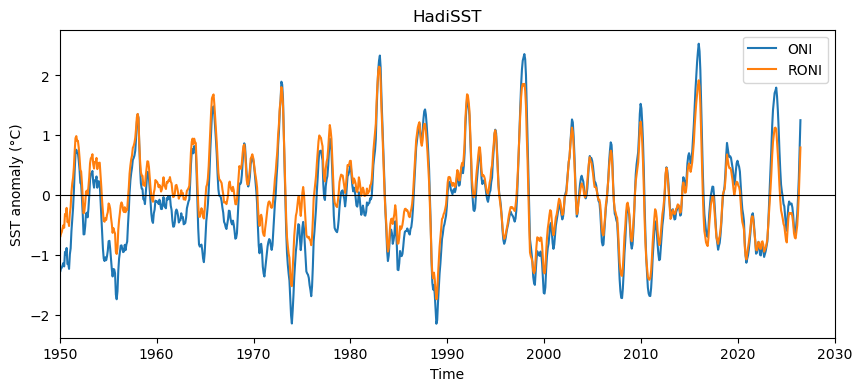

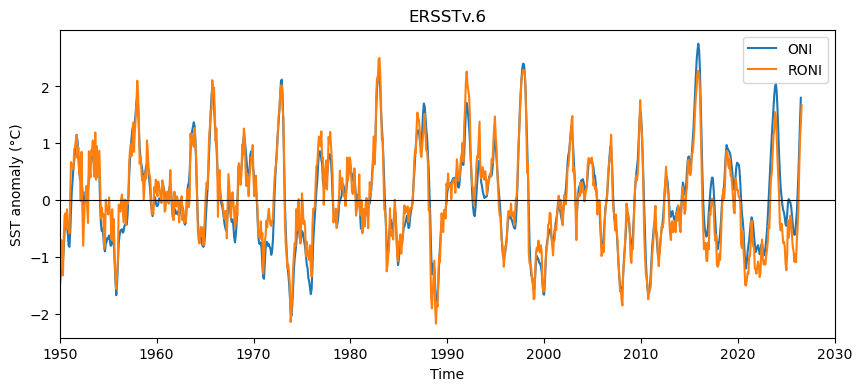

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(oni['time'], oni, label='ONI')
plt.plot(roni['time'], roni, label='RONI')
plt.xlim(pd.to_datetime("1950"), pd.to_datetime("2030"))


plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.xlabel('Time')
plt.ylabel('SST anomaly (°C)')
plt.title('HadiSST')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(oni_ersst['time'], oni_series, label='ONI')
plt.plot(roni_ersst['time'], roni_series, label='RONI')
plt.xlim(pd.to_datetime("1950"), pd.to_datetime("2030"))

plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.xlabel('Time')
plt.ylabel('SST anomaly (°C)')
plt.title('ERSSTv.6')
plt.show()

In [11]:
# extract predictor dataset (oni & roni)  
def get_oni_season(predictor_series, centre_month, year_offset=0):
    """Extract predictor values for seasons centered on a given month, relabeled by target year."""
    sub = oni_series[oni_series.index.month == centre_month].copy()
    sub.index = sub.index.year + year_offset # _.year 
    return sub

In [12]:
# # forecasting 1-month lead
# oni_ndj = get_oni_season (oni_series, centre_month = 12, year_offset = 1) # MAM following year 
# oni_fma = get_oni_season (oni_series, centre_month = 3, year_offset = 0) # JJA
# oni_mjj = get_oni_season (oni_series, centre_month = 6, year_offset = 0) # SON
# oni_aso = get_oni_season (oni_series, centre_month = 9, year_offset = 0) # DJF

# roni_ndj = get_oni_season (roni_series, centre_month = 12, year_offset = 1) # MAM following year 
# roni_fma = get_oni_season (roni_series, centre_month = 3, year_offset = 0) # JJA
# roni_mjj = get_oni_season (roni_series, centre_month = 6, year_offset = 0) # SON
# roni_aso = get_oni_season (roni_series, centre_month = 9, year_offset = 0) # DJF


In [13]:
# # forecasting with 3-month lead

# oni_son = get_oni_season(oni_series, centre_month=10, year_offset=1) # MAM
# oni_djf = get_oni_season(oni_series, centre_month= 1, year_offset=0) # JJA
# oni_mam = get_oni_season (oni_series, centre_month = 4, year_offset = 0) # SON
# oni_jja = get_oni_season (oni_series, centre_month = 7, year_offset = 1) # DJF

# roni_son = get_oni_season(roni_series, centre_month=10, year_offset=1) # MAM
# roni_djf = get_oni_season(roni_series, centre_month= 1, year_offset=0) # JJA
# roni_mam = get_oni_season (roni_series, centre_month = 4, year_offset = 0) # SON
# roni_jja = get_oni_season (roni_series, centre_month = 7, year_offset = 1) # DJF

In [14]:
# oni_ndj.loc[1998]
# roni_ndj.loc[1998]

In [15]:
# build non-overlapping rainfall seasons to start with, later maybe rolling season 

def seasonal_total(rain_series, season_months, year_offset=0):
    """season_months e.g. [3,4,5] for MAM. Handles DJF (crosses year boundary)
    automatically via year_offset if season_months=[12,1,2]."""
    sub = rain_series[rain_series.index.month.isin(season_months)].copy()
    
    if season_months == [12, 1, 2]:
        yr = sub.index.year.where(sub.index.month != 12, sub.index.year + 1) # if not 12, keet index year, if 12 add +1
    else:
        yr = sub.index.year
    
    total = sub.groupby(yr).sum() # total rainfall for 3 months
    counts = sub.groupby(yr).size() # number of months 
    total = total[counts == len(season_months)]  # keep only complete seasons, i.e. 3 months 
    total.index = total.index + year_offset
    return total


In [16]:
# rain_mam = seasonal_total(singlegrid_series, [3,4,5])
# rain_jja = seasonal_total(singlegrid_series, [6,7,8])
# rain_son = seasonal_total(singlegrid_series, [9,10,11])
# rain_djf = seasonal_total(singlegrid_series, [12,1,2])

In [17]:
# define Leave-One-Out-Cross_Validation function 
# For every observation, temporarily hide it, 
# use all the other observations to define the rainfall categories and train LDA, then predict the hidden observation.

def loocv_lda(X, rain_values): # X is predictor data 
    loo = LeaveOneOut() 
    n = len(rain_values) 
    preds = np.zeros(n, dtype=int) # stores LDA's predicted rainfall category for each year (below, near, above normal) 
    probs_all = np.zeros((n, 3)) # stores assigned probability LDA assigns to each category (adds up to 1) 
    obs_tercile = np.zeros(n, dtype=int) # stores actual observed rainfall category for each year 

    for train_idx, test_idx in loo.split(X): # generates training and testing indices from X predictor 
        q33, q67 = np.quantile(rain_values[train_idx], [1/3, 2/3]) # calculates 33rd and 67th percentiles using training data

        y_train = np.digitize(rain_values[train_idx], [q33, q67]) # converts rainfall data to catogories 0,1,2
        y_test  = np.digitize(rain_values[test_idx],  [q33, q67]) # does same for test data 

        lda_cv = LinearDiscriminantAnalysis() # creates LDA classifer: given predictor X, which rainfall tercile is most likely?
        lda_cv.fit(X[train_idx], y_train) # train only with training data 

        preds[test_idx]       = lda_cv.predict(X[test_idx]) # LDA predicts rainfall cateogry of test data 
        probs_all[test_idx]   = lda_cv.predict_proba(X[test_idx]) # LDA predicts probability for each rainfall category 
        obs_tercile[test_idx] = y_test # tells observed/acutal category of test data


    return preds, probs_all, obs_tercile


In [18]:
# Basic skill metrics (Heidke_skill_score -> hit/miss)

def hit_rate(preds, obs):
    return np.mean(preds == obs)

def heidke_skill_score(preds, obs, n_classes=3):
    n = len(obs)
    correct = np.sum(preds == obs)
    expected_correct = n / n_classes
    return (correct - expected_correct) / (n - expected_correct)

In [19]:
# Season / lead-time definitions

season_config = {
    'DJF': {'months': [12,1,2], 'center_1mo': 9,  'offset_1mo': 0, 'center_3mo': 7,  'offset_3mo': 1 }, # double check 
    'MAM': {'months': [3,4,5],  'center_1mo': 12, 'offset_1mo': 1, 'center_3mo': 10, 'offset_3mo': 1},
    'JJA': {'months': [6,7,8],  'center_1mo': 3,  'offset_1mo': 0, 'center_3mo': 1,  'offset_3mo': 0},
    'SON': {'months': [9,10,11],'center_1mo': 6,  'offset_1mo': 0, 'center_3mo': 4,  'offset_3mo': 0},
}

In [41]:
# build dataset and run LOOCV LDA with ONI 1month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(oni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_1mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=75, hit_rate=0.440, HSS=0.160
MAM: n=75, hit_rate=0.427, HSS=0.140
JJA: n=76, hit_rate=0.395, HSS=0.092
SON: n=76, hit_rate=0.474, HSS=0.211


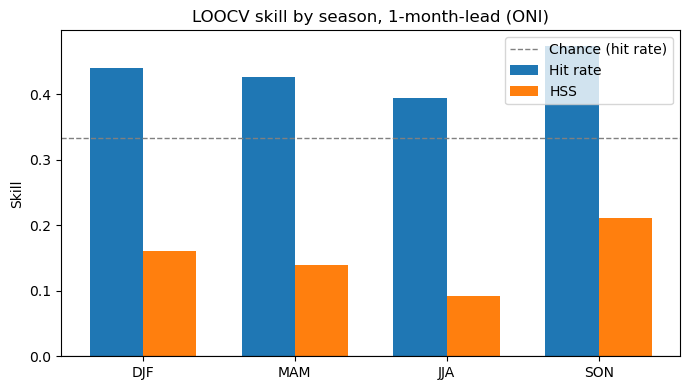

In [42]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 1-month-lead (ONI)')
ax.legend()
plt.tight_layout()
plt.show()

DJF: n=75, hit_rate=0.480, HSS=0.220
MAM: n=75, hit_rate=0.413, HSS=0.120
JJA: n=76, hit_rate=0.237, HSS=-0.145
SON: n=76, hit_rate=0.408, HSS=0.112


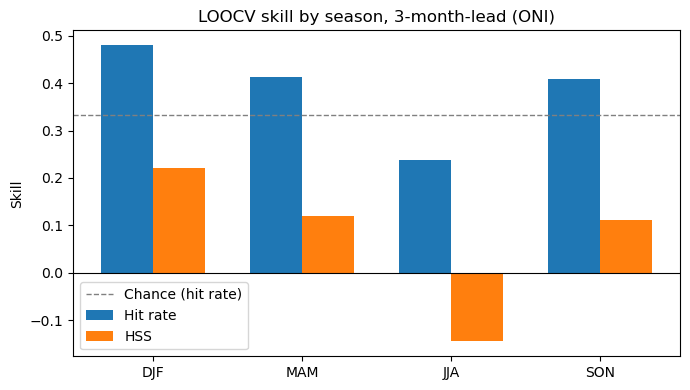

In [43]:
# build dataset and run LOOCV LDA with ONI 3month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(oni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_3mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")


seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 3-month-lead (ONI)')
ax.legend()
plt.tight_layout()
plt.show()
    

In [44]:
def plot_lda_1d(season_name, X_1d, y, ax=None, predictor_label='ONI'):
    """X_1d: shape (n,) or (n,1) - single predictor values
       y: tercile labels (0,1,2)"""
    X_1d = np.asarray(X_1d).reshape(-1, 1)
    
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_1d, y)   # full-data fit, for visualization only - not a skill claim
    
    x_min, x_max = X_1d.min() - 0.5, X_1d.max() + 0.5
    x_grid = np.linspace(x_min, x_max, 500).reshape(-1, 1)
    
    class_pred = lda.predict(x_grid)
    probs = lda.predict_proba(x_grid)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,4))
    
    # background strip showing predicted class region
    colors = ['#4575b4', '#ffffbf', '#d73027']  # below/near/above
    for i in range(len(x_grid)-1):
        ax.axvspan(x_grid[i,0], x_grid[i+1,0], color=colors[class_pred[i]], alpha=0.15, lw=0)
    
    # posterior probability curves
    labels = ['P(Below)', 'P(Near)', 'P(Above)']
    for c in range(3):
        ax.plot(x_grid, probs[:,c], color=colors[c], label=labels[c], linewidth=2)
    
    # actual observed data points, jittered slightly on y for visibility
    for c in range(3):
        mask = y == c
        ax.scatter(X_1d[mask], np.full(mask.sum(), -0.05), color=colors[c], 
                   edgecolor='k', s=40, zorder=5)
    
    # mark decision boundaries (where predicted class changes)
    boundaries = x_grid[:-1][np.diff(class_pred) != 0]
    for b in boundaries:
        ax.axvline(b[0], color='gray', linestyle='--', linewidth=1)
    
    ax.set_xlabel(predictor_label)
    ax.set_ylabel('Posterior probability')
    ax.set_ylim(-0.12, 1.05)
    ax.set_title(f'{season_name}: LDA decision regions ({predictor_label})')
    ax.legend(fontsize=8, loc='upper left')
    return ax



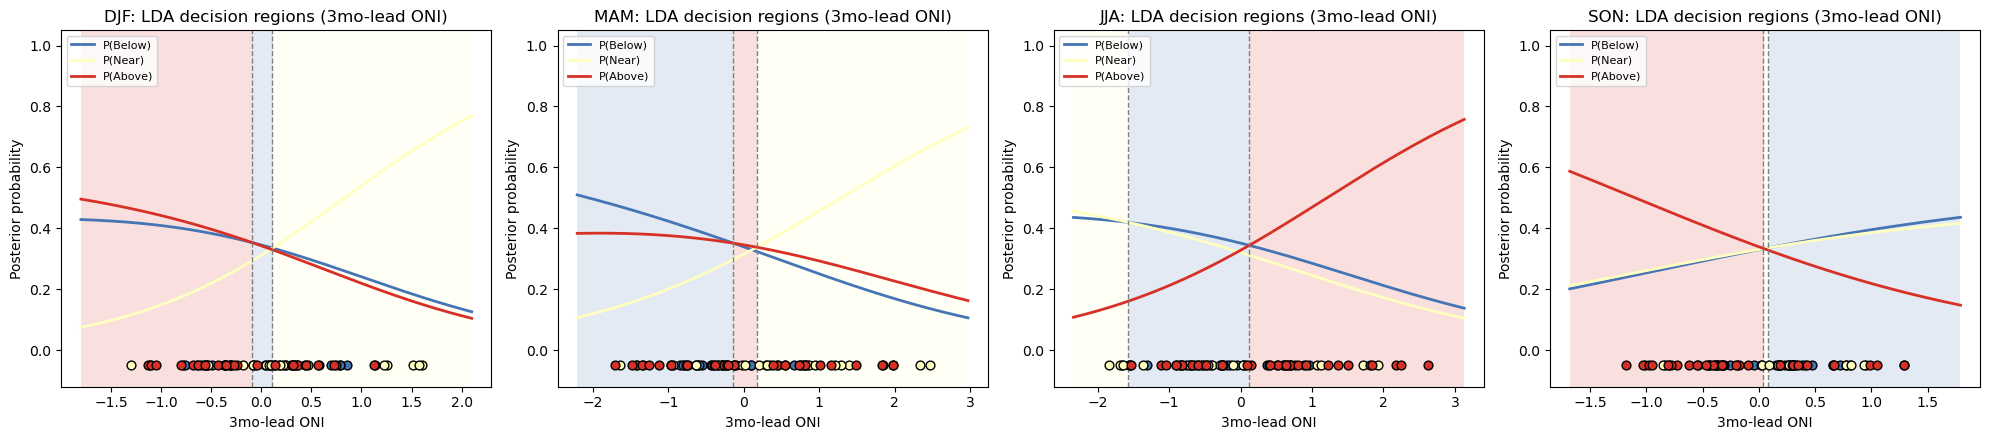

In [45]:
# 3 months oni
fig, axes = plt.subplots(1, 4, figsize=(20,4.5))

for ax, season_name in zip(axes, season_config.keys()):
    cfg = season_config[season_name]
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])
    oni_3mo.name = 'oni_3mo'
    rain.name = 'rain'
    
    df = pd.concat([oni_3mo, rain], axis=1).dropna()
    q33, q67 = df['rain'].quantile([1/3, 2/3])
    df['tercile'] = pd.cut(df['rain'], bins=[-np.inf,q33,q67,np.inf], labels=[0,1,2]).astype(int)
    
    plot_lda_1d(season_name, df['oni_3mo'].values, df['tercile'].values, ax=ax, 
                predictor_label='3mo-lead ONI')

plt.tight_layout()
plt.show()

In [46]:
# build dataset and run LOOCV LDA with RONI 1month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(roni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_1mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=75, hit_rate=0.440, HSS=0.160
MAM: n=75, hit_rate=0.427, HSS=0.140
JJA: n=76, hit_rate=0.395, HSS=0.092
SON: n=76, hit_rate=0.474, HSS=0.211


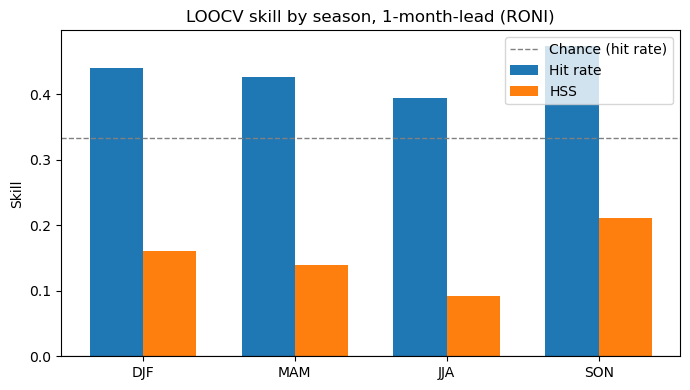

In [47]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 1-month-lead (RONI)')
ax.legend()
plt.tight_layout()
plt.show()
    

In [48]:
# build dataset and run LOOCV LDA with RONI 3month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(roni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_3mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=75, hit_rate=0.480, HSS=0.220
MAM: n=75, hit_rate=0.413, HSS=0.120
JJA: n=76, hit_rate=0.237, HSS=-0.145
SON: n=76, hit_rate=0.408, HSS=0.112


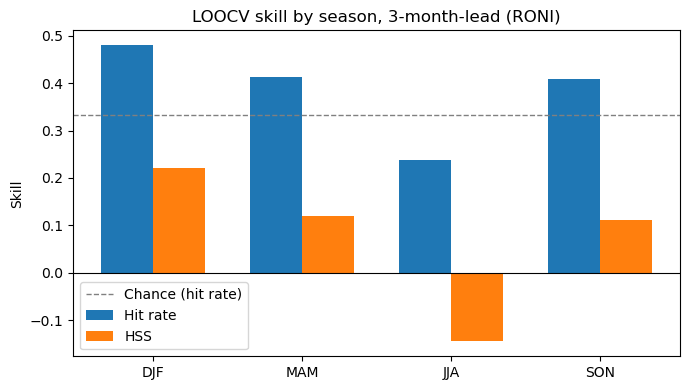

In [49]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 3-month-lead (RONI)')
ax.legend()
plt.tight_layout()
plt.show()

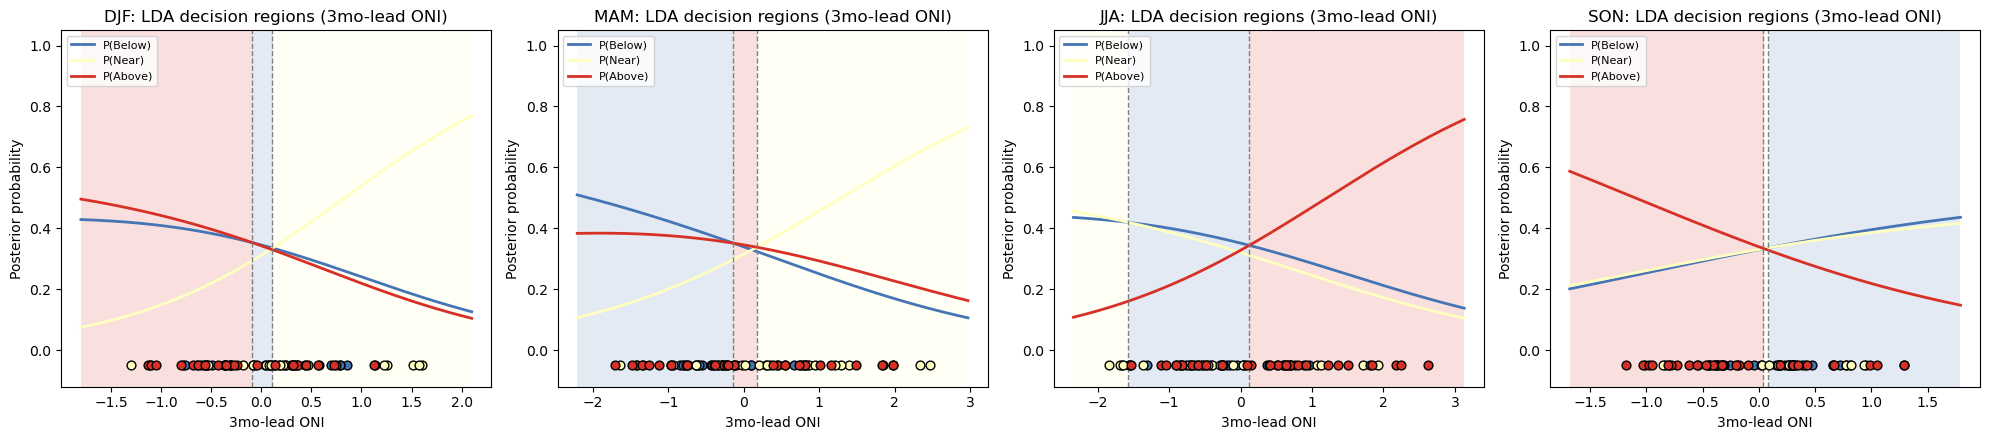

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20,4.5))

for ax, season_name in zip(axes, season_config.keys()):
    cfg = season_config[season_name]
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(singlegrid_series, cfg['months'])
    oni_3mo.name = 'oni_3mo'
    rain.name = 'rain'
    
    df = pd.concat([oni_3mo, rain], axis=1).dropna()
    q33, q67 = df['rain'].quantile([1/3, 2/3])
    df['tercile'] = pd.cut(df['rain'], bins=[-np.inf,q33,q67,np.inf], labels=[0,1,2]).astype(int)
    
    plot_lda_1d(season_name, df['oni_3mo'].values, df['tercile'].values, ax=ax, 
                predictor_label='3mo-lead ONI')

plt.tight_layout()
plt.show()

In [30]:
# check why exact same oni vs roni
# improving or worsening by time?
# leps

In [31]:
# compare hindcast access - how? leps? 